## Import libraries

In [52]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import seaborn as sns

MODEL_ROOT = Path.cwd().parents[1] / "models"
if str(MODEL_ROOT) not in sys.path:
    sys.path.insert(0, str(MODEL_ROOT))

from dinov3.layers.patch_embed import PatchEmbed
from dinov3.layers.rms_norm import RMSNorm
from dinov3.layers.layer_scale import LayerScale
from dinov3.layers.ffn_layers import Mlp
from dinov3.layers.rope_position_encoding import RopePositionEmbedding
from dinov3.layers.attention import SelfAttention, CausalSelfAttention

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Test Layers

### `PatchEmbed`

In [3]:
H, W = (224, 224)
C = 3
x = torch.randn(1, 3, 224, 224)
print("Input shape:", x.shape)

embed = PatchEmbed(
    img_size=H,
    patch_size=16, 
    in_chans=C,
    embed_dim=768
    )

out = embed(x)
print("Output shape:", out.shape)

Input shape: torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 196, 768])


### `RMSNorm`

In [4]:
x = torch.randn(1, 196, 768)
print("Input shape:", x.shape)

norm = RMSNorm(dim=768)

out = norm(x)
print("Output shape:", out.shape)

Input shape: torch.Size([1, 196, 768])
Output shape: torch.Size([1, 196, 768])


### `LayerScale`

In [5]:
x = torch.randn(1, 196, 768)
print("Input shape:", x.shape)

scaler = LayerScale(dim=768)

out = scaler(x)
print("Output shape:", out.shape)

Input shape: torch.Size([1, 196, 768])
Output shape: torch.Size([1, 196, 768])


### `Mlp`

In [6]:
x1 = torch.randn(2, 3, 4)
x2 = torch.randn(1, 5, 4)

x_list = [x1, x2]

mlp = Mlp(
    in_features=4,
    hidden_features=8,
    out_features=16
)

out = mlp.forward_list(x_list)
print("Output length:", len(out))

Output length: 2


### `RoPE`

In [33]:
embed_dim = 768
num_heads = 16
H = 14
W = 14

rope = RopePositionEmbedding(
    embed_dim=embed_dim, 
    num_heads=num_heads,
)

out = rope(H=H, W=W)
print("Output shape:", out[0].shape, out[1].shape)

Output shape: torch.Size([196, 48]) torch.Size([196, 48])


cos: (196, 48)
sin: (196, 48)


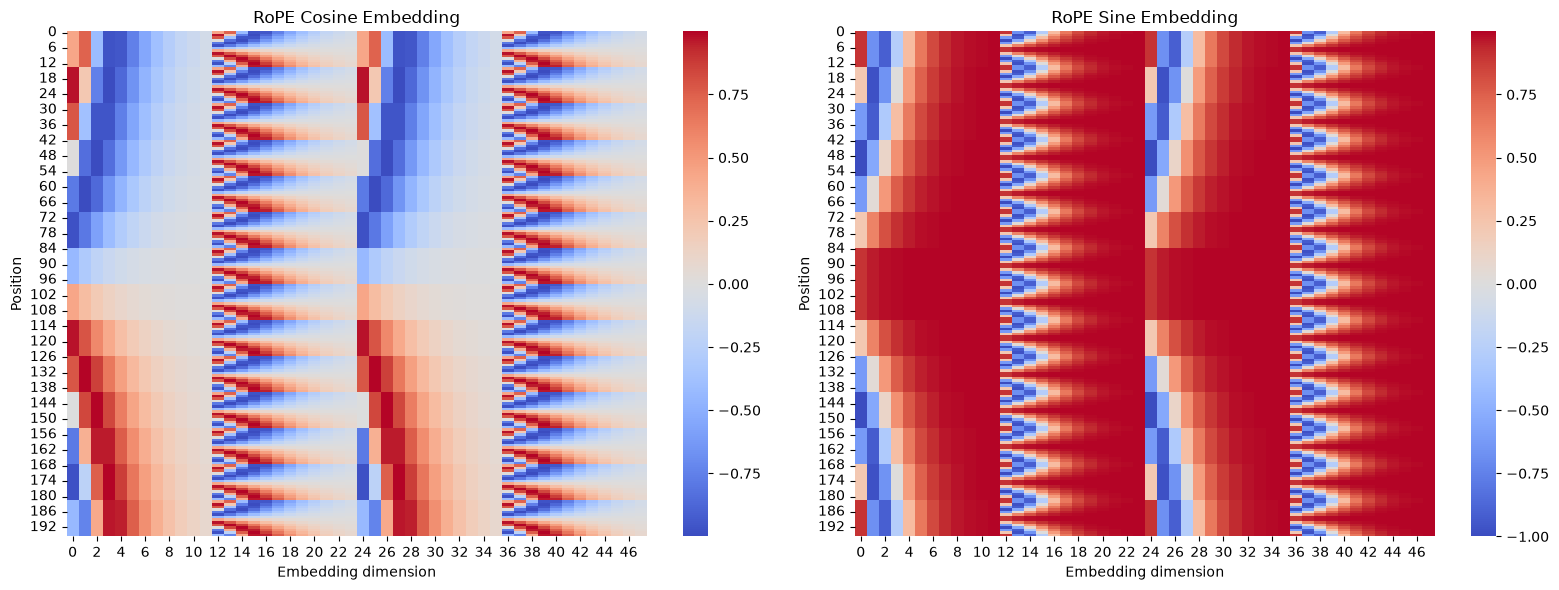

In [34]:
# Plot the positional embedding
cos_emb = out[0].detach().cpu().numpy()
sin_emb = out[1].detach().cpu().numpy()

print("cos:", cos_emb.shape)
print("sin:", sin_emb.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cos_emb,
    cmap="coolwarm",
    ax=axes[0],
    center=0
)
axes[0].set_title("RoPE Cosine Embedding")
axes[0].set_xlabel("Embedding dimension")
axes[0].set_ylabel("Position")

sns.heatmap(
    sin_emb,
    cmap="coolwarm",
    ax=axes[1],
    center=0
)
axes[1].set_title("RoPE Sine Embedding")
axes[1].set_xlabel("Embedding dimension")
axes[1].set_ylabel("Position")

plt.tight_layout()
plt.show()

### `SelfAttention`

In [55]:
x = torch.randn(1, 196, embed_dim)
print("Input shape:", x.shape)

self_attention = SelfAttention(embed_dim, num_heads)
causal_self_attention = CausalSelfAttention(embed_dim, num_heads)
rope_out = rope(H=H, W=W)

self_attention_out = self_attention(x, rope=rope_out)
causal_self_attention_out = causal_self_attention(x)
print("Self Attention Output shape:", self_attention_out.shape)
print("Causal Self Attention Output shape:", causal_self_attention_out.shape)

Input shape: torch.Size([1, 196, 768])
Self Attention Output shape: torch.Size([1, 196, 768])
Causal Self Attention Output shape: torch.Size([1, 196, 768])
